# Predicting Insurance Claim Amounts

## Problem Statement

The objective of this project is to predict medical insurance charges based on personal information such as age, BMI, smoking status, gender, number of children, and region.

This is a Regression Machine Learning problem because the target variable (charges) is continuous.

A Linear Regression model will be trained to estimate insurance claim amounts and its performance will be evaluated using MAE and RMSE.

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Description

The dataset contains information about insurance beneficiaries.

Features:
- age: Age of the person
- sex: Gender
- bmi: Body Mass Index
- children: Number of dependents
- smoker: Smoking status
- region: Residential area

Target Variable:
- charges: Medical insurance cost

In [56]:
#Loading Dataset
df = pd.read_csv("insurance.csv")

### Dataset information

In [57]:
df.shape

(1338, 7)

In [58]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [59]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [61]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Cleaning

The dataset is checked for missing values and categorical variables are converted into numerical form using Label Encoding.

In [62]:
#Checking Missing Vaues
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [63]:
### Encoding Categorial Columns

In [64]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [65]:
#Verifying Dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Exploratory Data Analysis

The visualizations show that:

- Insurance charges generally increase with age.
- Higher BMI values are associated with higher insurance costs.
- Smokers tend to have significantly higher insurance charges compared to non-smokers.
- The correlation heatmap helps identify relationships between features and insurance charges.

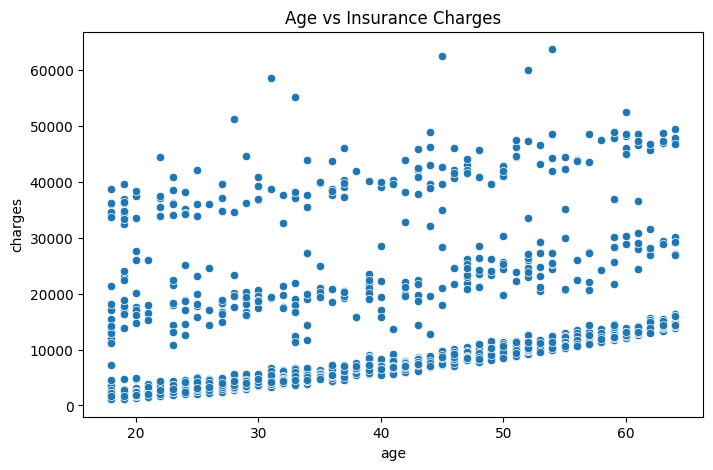

In [66]:
#Visualization of Age vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

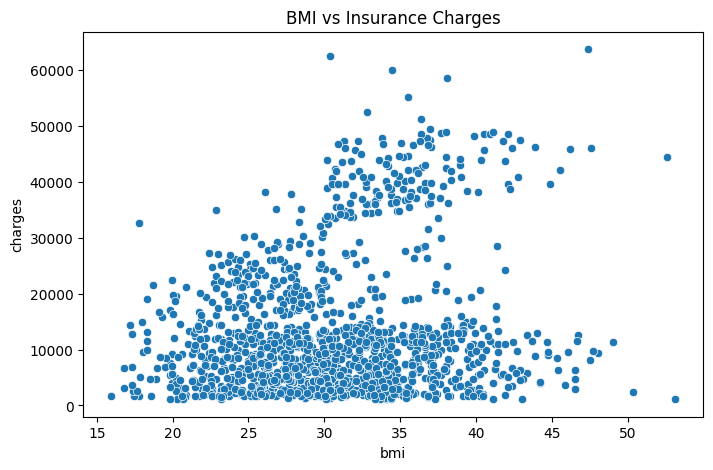

In [67]:
#Visualization of BMI vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

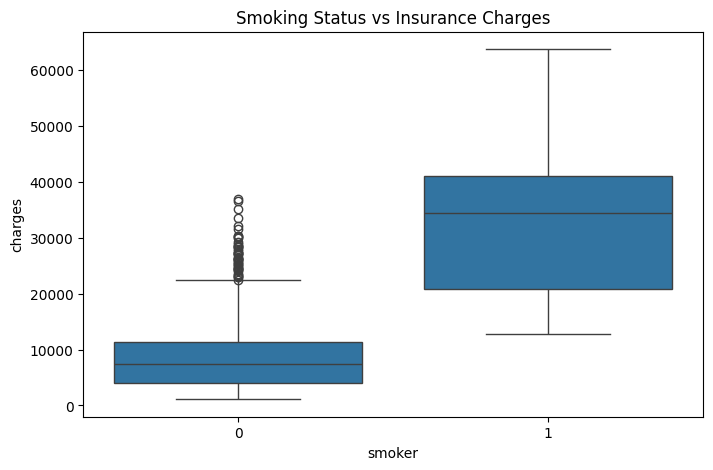

In [68]:
#Visualization of smoking status effect
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking Status vs Insurance Charges")
plt.show()

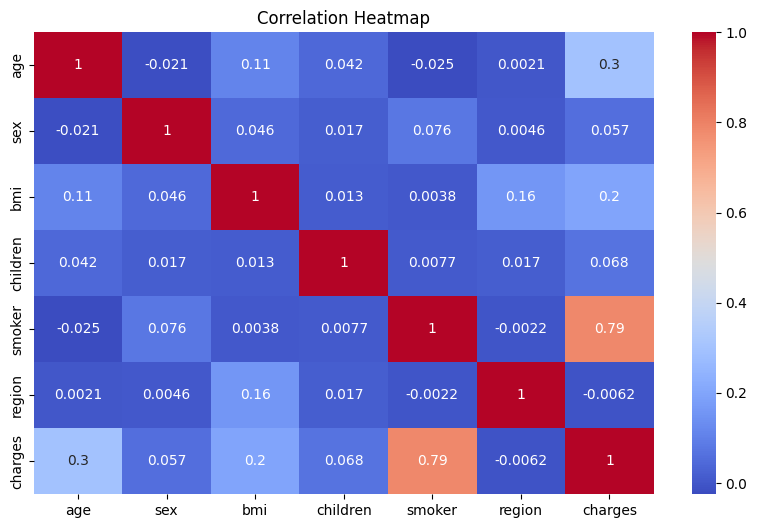

In [69]:
#Corealtion Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Features and Target

In [70]:
X = df.drop('charges', axis=1)

y = df['charges']

### Splitting Data

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

A Linear Regression model is trained to predict insurance charges using the available features.
## Model Evaluation

The model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [72]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [73]:
y_pred = model.predict(X_test)

In [74]:
print(y_pred[:5])

[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079 ]


In [75]:
#Model Evaluation
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 4186.508898366433
RMSE : 5799.587091438356
R2 Score : 0.7833463107364539


### Actual vs Predicted Charges VIsualization

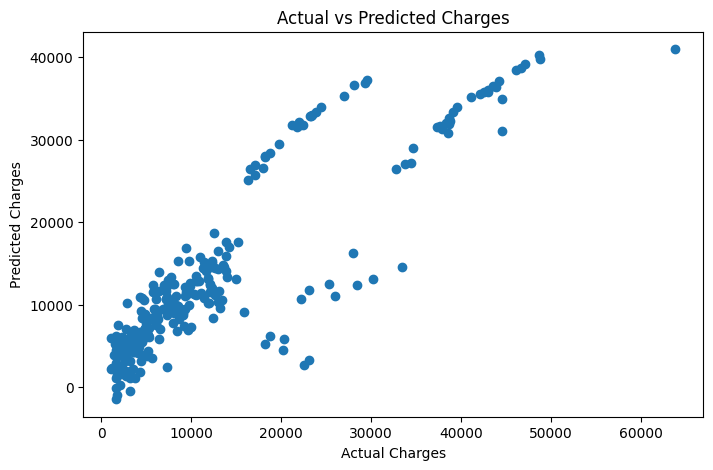

In [76]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

Residual Plot

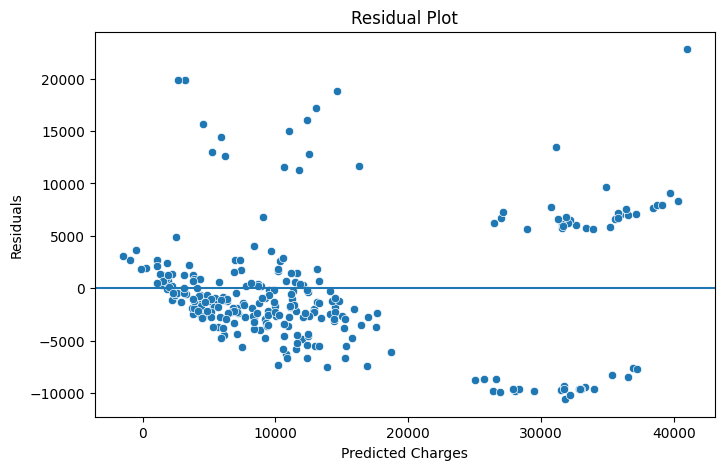

In [77]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Comparison of Actual vs Predicted Charges

In [78]:
results = pd.DataFrame({
    'Actual Charges': y_test,
    'Predicted Charges': y_pred
})

results.head(10)

,Actual Charges,Predicted Charges
764,9095.06825,8924.407244
887,5272.17580,7116.295018
890,29330.98315,36909.013521
1293,9301.89355,9507.874691
259,33750.29180,27013.350008
1312,4536.25900,10790.779562
899,2117.33885,226.298446
752,14210.53595,16942.715999
1286,3732.62510,1056.630794
707,10264.44210,11267.919973


## Feature Impact Analysis

The coefficients indicate how each feature influences insurance charges.

Positive coefficients increase the predicted charges, while negative coefficients decrease them.

Smoking status, age, and BMI generally have strong effects on insurance costs.

In [79]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,smoker,23647.818096
3,children,425.091456
2,bmi,335.781491
0,age,257.056264
1,sex,-18.791457
5,region,-271.284266


## Conclusion

A Linear Regression model was developed to predict medical insurance claim amounts using personal information.

Key Findings:

• Age has a positive relationship with insurance charges.
• Higher BMI values generally lead to higher medical costs.
• Smokers incur significantly higher insurance expenses compared to non-smokers.
• Linear Regression successfully predicts insurance charges with reasonable accuracy.

Evaluation Metrics:

• Mean Absolute Error (MAE) was used to measure average prediction error.
• Root Mean Squared Error (RMSE) measured overall prediction performance.
• R² Score indicated the model's ability to explain variation in insurance charges.

Overall, the model demonstrates the effectiveness of machine learning in estimating medical insurance costs based on personal characteristics.